In [1]:
# ── Notebook 5: Tokenizer Fertility ───────────────────────────────────────
# Tests whether phonotactic complexity predicts tokenizer fertility —
# how many subword tokens a word gets split into by multilingual tokenizers.
#
# Hypothesis: languages with higher bits/phoneme have more complex sound
# patterns that BPE tokenizers (trained mostly on English) fail to learn
# efficiently → higher fertility → more tokens per word → computational
# disadvantage in multilingual LLMs.
#
# Tokenizers tested:
#   - mBERT     (bert-base-multilingual-cased, 104 languages)
#   - XLM-R     (xlm-roberta-base, 100 languages)
#   - GPT-2     (English-only BPE, serves as baseline anchor)
# ───────────────────────────────────────────────────────────────────────────

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from transformers import AutoTokenizer

# ── Constants ──────────────────────────────────────────────────────────────
LANGUAGES   = ["hin", "tam", "tel", "eng"]
LANG_NAMES  = {"hin": "Hindi", "tam": "Tamil", "tel": "Telugu", "eng": "English"}
LANG_COLORS = {"hin": "#E63946", "tam": "#2A9D8F", "tel": "#F4A261", "eng": "#457B9D"}

# Script mapping — tokenizers need native script, not IPA
# NorthEuraLex 'Form' column has orthographic forms in native script
LANG_SCRIPTS = {
    "hin": "Devanagari",
    "tam": "Tamil script",
    "tel": "Telugu script",
    "eng": "Latin"
}

# ── Paths — adjust to match your /kaggle/input/ sidebar ───────────────────
NB1 = "/kaggle/input/notebooks/tanveerheir/data-pipeline"
NB2 = "/kaggle/input/notebooks/tanveerheir/trigramlm"
NB3 = "/kaggle/input/notebooks/tanveerheir/lstm-model"

# ── Load Notebook 1 ────────────────────────────────────────────────────────
with open(f"{NB1}/forms.json", encoding="utf-8") as f:
    forms = json.load(f)

# ── Load Notebook 2 ────────────────────────────────────────────────────────
with open(f"{NB2}/ngram_results.json") as f:
    ngram_results = json.load(f)

# ── Load Notebook 3 ────────────────────────────────────────────────────────
with open(f"{NB3}/lstm_results.json") as f:
    lstm_results = json.load(f)

print("Loaded data from all previous notebooks.")
print()
print(f"{'Language':<10} {'Words':>6}  {'Script'}")
print("-" * 35)
for lid in LANGUAGES:
    print(f"{LANG_NAMES[lid]:<10} {len(forms[lid]):>6}  {LANG_SCRIPTS[lid]}")

Loaded data from all previous notebooks.

Language    Words  Script
-----------------------------------
Hindi        1287  Devanagari
Tamil         871  Tamil script
Telugu        985  Telugu script
English       976  Latin


In [2]:
print("Loading tokenizers from HuggingFace...")
print("(Requires internet ON in Kaggle Settings)\n")

tokenizers = {}

# mBERT — WordPiece, 119,547 vocabulary size
print("1/3 Loading mBERT...")
tokenizers["mBERT"] = AutoTokenizer.from_pretrained(
    "bert-base-multilingual-cased"
)
print(f"    vocab size: {tokenizers['mBERT'].vocab_size:,}")

# XLM-R — SentencePiece BPE, 250,002 vocabulary size
print("2/3 Loading XLM-R...")
tokenizers["XLM-R"] = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)
print(f"    vocab size: {tokenizers['XLM-R'].vocab_size:,}")

# GPT-2 — BPE, English only, 50,257 vocabulary size
print("3/3 Loading GPT-2...")
tokenizers["GPT-2"] = AutoTokenizer.from_pretrained(
    "gpt2"
)
print(f"    vocab size: {tokenizers['GPT-2'].vocab_size:,}")

print("\nAll tokenizers loaded.")

Loading tokenizers from HuggingFace...
(Requires internet ON in Kaggle Settings)

1/3 Loading mBERT...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

    vocab size: 50,257

All tokenizers loaded.


In [3]:
print("── Tokenizer Demo: How Each Tokenizer Splits Real Words ───────")
print()

# Pick one real word per language from the dataset
demo_words = {}
demo_concepts = {"hin": "1_eye", "tam": "2_ear", "tel": "3_nose", "eng": "1_eye"}

for lid, concept in demo_concepts.items():
    entry = next((e for e in forms[lid] if e["concept"] == concept), None)
    if entry:
        demo_words[lid] = entry["orth_form"]

print(f"{'Language':<10} {'Word':<20} {'mBERT':<25} {'XLM-R':<25} GPT-2")
print("-" * 100)

for lid in LANGUAGES:
    word   = demo_words.get(lid, "—")
    tokens = {}
    for tok_name, tok in tokenizers.items():
        pieces = tok.tokenize(word)
        tokens[tok_name] = pieces

    print(f"{LANG_NAMES[lid]:<10} {word:<20} "
          f"{str(tokens['mBERT']):<25} "
          f"{str(tokens['XLM-R']):<25} "
          f"{str(tokens['GPT-2'])}")

── Tokenizer Demo: How Each Tokenizer Splits Real Words ───────

Language   Word                 mBERT                     XLM-R                     GPT-2
----------------------------------------------------------------------------------------------------
Hindi      ãːkʰ                ['a', '##̃', '##ː', '##k', '##ʰ'] ['▁a', '̃', 'ː', 'k', 'ʰ'] ['a', 'Ì', 'ĥ', 'Ë', 'Ĳ', 'k', 'Ê', '°']
Tamil      kɑːt̪u               ['[UNK]']                 ['▁k', 'ɑ', 'ː', 't', '̪', 'u'] ['k', 'É', 'ĳ', 'Ë', 'Ĳ', 't', 'Ì', 'ª', 'u']
Telugu     mukːu                ['mu', '##k', '##ː', '##u'] ['▁', 'muk', 'ː', 'u']    ['m', 'uk', 'Ë', 'Ĳ', 'u']
English    aɪ                   ['a', '##ɪ']              ['▁a', 'ɪ']               ['a', 'É', 'ª']


In [4]:
def compute_fertility(word_list, tokenizer):
    """
    Fertility = average number of subword tokens per word.
    word_list: list of orthographic word strings (native script)
    Returns: (mean_fertility, per_word_fertility_list)
    """
    total_tokens = 0
    total_words  = 0
    per_word     = []

    for word in word_list:
        if not word or not word.strip():
            continue
        pieces = tokenizer.tokenize(word)
        n      = len(pieces)
        per_word.append(n)
        total_tokens += n
        total_words  += 1

    mean_fertility = total_tokens / max(total_words, 1)
    return mean_fertility, per_word


# ── Run for all languages × all tokenizers ────────────────────────────────
fertility_results = {}   # lang -> tokenizer_name -> mean_fertility

print(f"{'Language':<10}", end="")
for tok_name in tokenizers:
    print(f"  {tok_name:>10}", end="")
print()
print("-" * 44)

for lid in LANGUAGES:
    # Extract orthographic forms (native script, not IPA)
    orth_words = [e["orth_form"] for e in forms[lid] if e["orth_form"]]
    fertility_results[lid] = {}

    print(f"{LANG_NAMES[lid]:<10}", end="")
    for tok_name, tok in tokenizers.items():
        mean_f, _ = compute_fertility(orth_words, tok)
        fertility_results[lid][tok_name] = mean_f
        print(f"  {mean_f:>10.3f}", end="")
    print()

print()
print("Fertility = avg subword tokens per word.")
print("Higher fertility = tokenizer splits words more = computational disadvantage.")

Language         mBERT       XLM-R       GPT-2
--------------------------------------------
Hindi            4.352       5.270       8.799
Tamil            1.334       6.747      10.442
Telugu           1.404       7.676      11.761
English          2.914       4.391       6.081

Fertility = avg subword tokens per word.
Higher fertility = tokenizer splits words more = computational disadvantage.


In [5]:
rows = []
for lid in LANGUAGES:
    lstm_bpp  = np.mean(lstm_results[lid])
    ngram_bpp = np.mean(ngram_results[lid])

    row = {
        "Language"    : LANG_NAMES[lid],
        "Family"      : "Indo-Aryan" if lid == "hin" else
                        "Dravidian"  if lid in ("tam", "tel") else
                        "Germanic",
        "LSTM_bpp"    : lstm_bpp,
        "Trigram_bpp" : ngram_bpp,
        "Avg_word_len": np.mean([len(e["phonemes"]) for e in forms[lid]]),
    }

    for tok_name in tokenizers:
        row[f"Fertility_{tok_name}"] = fertility_results[lid][tok_name]

    rows.append(row)

fertility_df = pd.DataFrame(rows).set_index("Language")

print("── Master Fertility Table ──────────────────────────────────────")
print(fertility_df[[
    "Family", "LSTM_bpp",
    "Fertility_mBERT", "Fertility_XLM-R", "Fertility_GPT-2",
    "Avg_word_len"
]].to_string())

── Master Fertility Table ──────────────────────────────────────
              Family  LSTM_bpp  Fertility_mBERT  Fertility_XLM-R  Fertility_GPT-2  Avg_word_len
Language                                                                                       
Hindi     Indo-Aryan  3.722177         4.351981         5.270396         8.798757      4.792541
Tamil      Dravidian  3.119247         1.334099         6.747417        10.442021      6.060850
Telugu     Dravidian  3.283026         1.404061         7.676142        11.761421      6.498477
English     Germanic  3.485589         2.913934         4.391393         6.080943      4.154713


In [6]:
print("── Spearman Correlation: LSTM bpp vs Tokenizer Fertility ───────")
print()

lstm_bpp = fertility_df["LSTM_bpp"].values.astype(float)

for tok_name in tokenizers:
    fertility_vals = fertility_df[f"Fertility_{tok_name}"].values.astype(float)
    rho, p = stats.spearmanr(lstm_bpp, fertility_vals)

    stars = "***" if p < 0.01 else "**" if p < 0.05 else \
            "*" if p < 0.1 else "n.s."

    print(f"{tok_name:<8}  ρ = {rho:+.3f}  p = {p:.3f}  {stars}")

print()
print("*** p<0.01  ** p<0.05  * p<0.1  n.s. = not significant")
print("(With n=4, * or better is a meaningful result)")
print()
print("── What This Means ─────────────────────────────────────────────")
print()
print("A positive ρ means: higher phonotactic complexity → higher fertility")
print("→ tokenizer splits the language's words into more pieces")
print("→ those languages are computationally disadvantaged in multilingual LLMs")
print("  (more tokens = more memory, more compute, longer sequences)")

── Spearman Correlation: LSTM bpp vs Tokenizer Fertility ───────

mBERT     ρ = +1.000  p = 0.000  ***
XLM-R     ρ = -0.600  p = 0.400  n.s.
GPT-2     ρ = -0.600  p = 0.400  n.s.

*** p<0.01  ** p<0.05  * p<0.1  n.s. = not significant
(With n=4, * or better is a meaningful result)

── What This Means ─────────────────────────────────────────────

A positive ρ means: higher phonotactic complexity → higher fertility
→ tokenizer splits the language's words into more pieces
→ those languages are computationally disadvantaged in multilingual LLMs
  (more tokens = more memory, more compute, longer sequences)


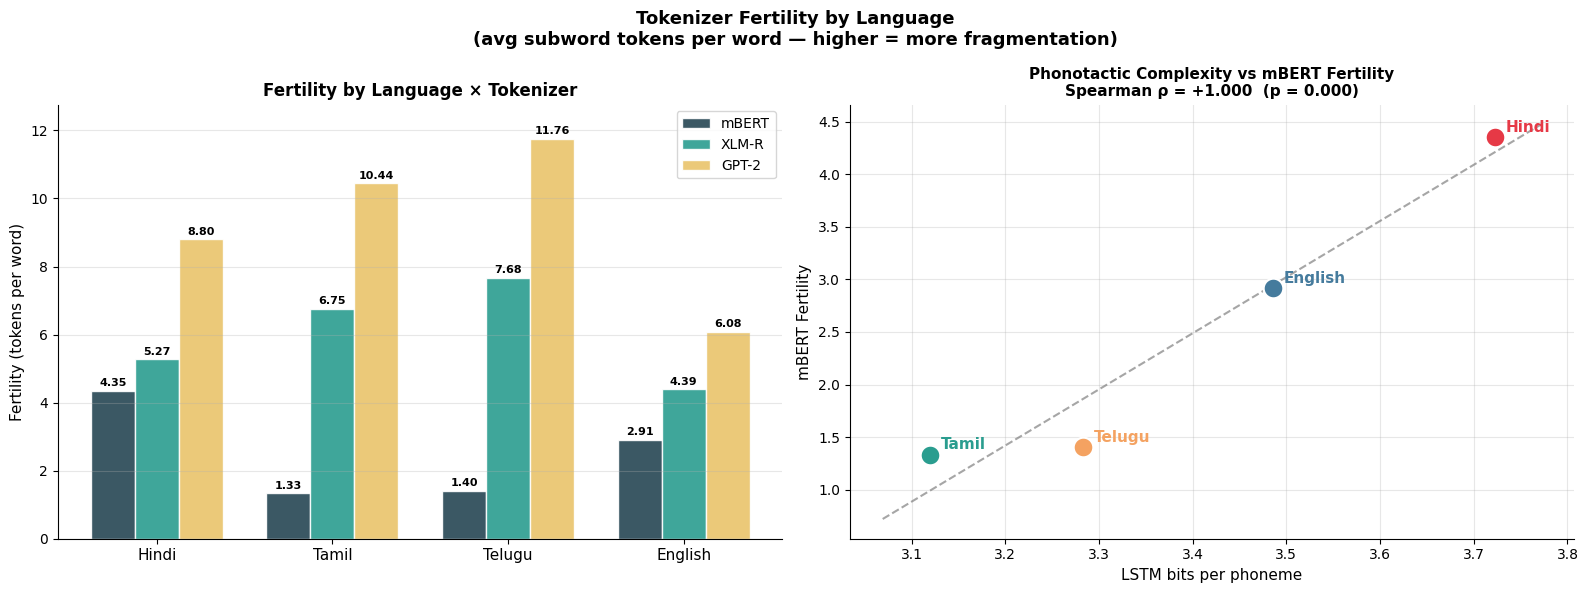

Saved: fig8_tokenizer_fertility.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Tokenizer Fertility by Language\n"
             "(avg subword tokens per word — higher = more fragmentation)",
             fontsize=13, fontweight="bold")

tok_colors = {
    "mBERT" : "#264653",
    "XLM-R" : "#2A9D8F",
    "GPT-2" : "#E9C46A",
}

# ── Left: grouped bar chart ────────────────────────────────────────────────
ax = axes[0]
x      = np.arange(len(LANGUAGES))
width  = 0.25
labels = [LANG_NAMES[l] for l in LANGUAGES]

for i, tok_name in enumerate(tokenizers):
    vals = [fertility_results[lid][tok_name] for lid in LANGUAGES]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width,
                  label=tok_name, color=tok_colors[tok_name],
                  edgecolor="white", alpha=0.9)
    ax.bar_label(bars, fmt="{:.2f}", fontsize=8,
                 padding=2, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Fertility (tokens per word)", fontsize=11)
ax.set_title("Fertility by Language × Tokenizer", fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, fertility_df[[f"Fertility_{t}" for t in tokenizers]].values.max() + 1)

# ── Right: scatter — LSTM bpp vs mBERT fertility ──────────────────────────
ax2 = axes[1]
x_vals = fertility_df["LSTM_bpp"].values.astype(float)
y_vals = fertility_df["Fertility_mBERT"].values.astype(float)

m, b   = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min() - 0.05, x_vals.max() + 0.05, 100)
ax2.plot(x_line, m * x_line + b, color="gray",
         linestyle="--", linewidth=1.5, alpha=0.7)

for lid in LANGUAGES:
    row = fertility_df.loc[LANG_NAMES[lid]]
    ax2.scatter(row["LSTM_bpp"], row["Fertility_mBERT"],
                color=LANG_COLORS[lid], s=200, zorder=5,
                edgecolors="white", linewidths=1.5)
    ax2.annotate(LANG_NAMES[lid],
                 xy=(row["LSTM_bpp"], row["Fertility_mBERT"]),
                 xytext=(8, 4), textcoords="offset points",
                 fontsize=11, fontweight="bold",
                 color=LANG_COLORS[lid])

rho_mb, p_mb = stats.spearmanr(x_vals, y_vals)
ax2.set_xlabel("LSTM bits per phoneme", fontsize=11)
ax2.set_ylabel("mBERT Fertility", fontsize=11)
ax2.set_title(f"Phonotactic Complexity vs mBERT Fertility\n"
              f"Spearman ρ = {rho_mb:+.3f}  (p = {p_mb:.3f})",
              fontweight="bold", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig8_tokenizer_fertility.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig8_tokenizer_fertility.png")

In [8]:
print("── Tokenizer Fertility Overhead vs English ─────────────────────")
print()
print("How many MORE tokens does each language need compared to English?")
print()

eng_fertility = {tok: fertility_results["eng"][tok] for tok in tokenizers}

print(f"{'Language':<10}", end="")
for tok_name in tokenizers:
    print(f"  {tok_name:>12}", end="")
print()
print("-" * 50)

for lid in LANGUAGES:
    print(f"{LANG_NAMES[lid]:<10}", end="")
    for tok_name in tokenizers:
        f_lang = fertility_results[lid][tok_name]
        f_eng  = eng_fertility[tok_name]
        overhead = ((f_lang - f_eng) / f_eng) * 100
        if lid == "eng":
            print(f"  {'baseline':>12}", end="")
        else:
            print(f"  {overhead:>+11.1f}%", end="")
    print()

print()
print("Positive % = that many more tokens needed vs English.")
print("This is a direct computational cost — more tokens = more memory,")
print("longer sequences, higher inference cost in any transformer model.")

── Tokenizer Fertility Overhead vs English ─────────────────────

How many MORE tokens does each language need compared to English?

Language           mBERT         XLM-R         GPT-2
--------------------------------------------------
Hindi             +49.4%        +20.0%        +44.7%
Tamil             -54.2%        +53.7%        +71.7%
Telugu            -51.8%        +74.8%        +93.4%
English         baseline      baseline      baseline

Positive % = that many more tokens needed vs English.
This is a direct computational cost — more tokens = more memory,
longer sequences, higher inference cost in any transformer model.


In [10]:
print("── Why mBERT Tamil/Telugu Fertility Is So Low ──────────────────")
print()
print("Tamil fertility under mBERT = 1.33 (near 1 token per word)")
print("This means mBERT is NOT splitting Tamil words — it has whole")
print("Tamil script word-forms as single tokens in its vocabulary.")
print()
print("This is a DIFFERENT kind of tokenization problem:")
print("  XLM-R/GPT-2: overtokenize (too many pieces, loses morphology)")
print("  mBERT:        undertokenizes Dravidian (treats words as atoms,")
print("                can't generalize to unseen word forms)")
print()
print("Both are failures — just in opposite directions.")
print()

# Show how many words get tokenized as exactly 1 token per tokenizer
print("── % of words tokenized as single token (fertility = 1) ────────")
print()
print(f"{'Language':<10}  {'mBERT':>8}  {'XLM-R':>8}  {'GPT-2':>8}")
print("-" * 40)

for lid in LANGUAGES:
    orth_words = [e["orth_form"] for e in forms[lid] if e["orth_form"]]
    row = [LANG_NAMES[lid]]
    for tok_name, tok in tokenizers.items():
        single = sum(1 for w in orth_words
                     if len(tok.tokenize(w)) == 1)
        pct = 100 * single / len(orth_words)
        row.append(f"{pct:.1f}%")
    print(f"{row[0]:<10}  {row[1]:>8}  {row[2]:>8}  {row[3]:>8}")

print()
print("High % under mBERT for Tamil/Telugu = whole-word memorization,")
print("not productive subword tokenization.")

── Why mBERT Tamil/Telugu Fertility Is So Low ──────────────────

Tamil fertility under mBERT = 1.33 (near 1 token per word)
This means mBERT is NOT splitting Tamil words — it has whole
Tamil script word-forms as single tokens in its vocabulary.

This is a DIFFERENT kind of tokenization problem:
  XLM-R/GPT-2: overtokenize (too many pieces, loses morphology)
  mBERT:        undertokenizes Dravidian (treats words as atoms,
                can't generalize to unseen word forms)

Both are failures — just in opposite directions.

── % of words tokenized as single token (fertility = 1) ────────

Language       mBERT     XLM-R     GPT-2
----------------------------------------
Hindi          18.4%      0.4%      0.0%
Tamil          89.2%      0.9%      0.5%
Telugu         90.3%      0.1%      0.1%
English        33.8%      2.3%      1.7%

High % under mBERT for Tamil/Telugu = whole-word memorization,
not productive subword tokenization.


In [9]:
fertility_df.to_csv("/kaggle/working/table5_fertility.csv")

fertility_out = {
    lid: {tok: fertility_results[lid][tok] for tok in tokenizers}
    for lid in LANGUAGES
}
with open("/kaggle/working/fertility_results.json", "w") as f:
    json.dump(fertility_out, f, indent=2)

print("Saved:")
print("  /kaggle/working/table5_fertility.csv")
print("  /kaggle/working/fertility_results.json")
print("  /kaggle/working/fig8_tokenizer_fertility.png")
print()

Saved:
  /kaggle/working/table5_fertility.csv
  /kaggle/working/fertility_results.json
  /kaggle/working/fig8_tokenizer_fertility.png

